# <center>Project 03: Linear Regression</center>

# Thông tin sinh viên

- Họ và tên: Trần Phụng Đình
- MSSV: 23127527
- Lớp: 23CLC01

# Import

In [1]:
# %pip install pandas numpy seaborn matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import thêm dữ thư viện nếu cần

# Đọc dữ liệu

In [3]:
# Đọc dữ liệu  bằng pandas
train = pd.read_csv('p03.train.csv')
test = pd.read_csv('p03.test.csv')

# Lấy các đặc trưng X và giá trị mục tiêu y cho các tập huấn luyện (train) và kiểm tra (test)
X_train = train.iloc[:, :-1]    # Dataframe (chứa 5 đặc trưng huấn luyện)
y_train = train.iloc[:, -1]     # Series    (chứa 1 giá trị mục tiêu huấn luyện)

X_test = test.iloc[:, :-1]      # Dataframe (chứa 5 đặc trưng kiểm tra)
y_test = test.iloc[:, -1]       # Series    (chứa 1 giá trị mục tiêu kiểm tra)

# Sinh viên có thể sử dụng các khác nếu cần
X_train_np = np.hstack([np.ones((len(X_train), 1)), X_train.to_numpy()])
y_train_np = y_train.to_numpy().reshape(-1, 1)
X_test_np = np.hstack([np.ones((len(X_test), 1)), X_test.to_numpy()])
y_test_np = y_test.to_numpy().reshape(-1, 1)


feature_names = train.columns[:-1]
target_name = train.columns[-1]

# Cài đặt hàm

In [4]:
# Cài đặt các hàm cần thiết ở đây
def mse(y_true, y_pred):
    """Mean Squared Error"""
    return np.mean((y_true - y_pred) ** 2)


def train_linear_regression(X, y):
    """Tính theta bằng công thức đóng"""
    return np.linalg.inv(X.T @ X) @ X.T @ y


def print_regression_formula(theta, feature_names):
    """In công thức hồi quy tuyến tính"""
    formula = f"y = {theta[0,0]:.3f}"
    for i, feat in enumerate(feature_names):
        formula += f" + {theta[i+1,0]:.3f} * {feat}"
    print(formula)



*Chú thích: Cần có docstrings cho các hàm.*

# Yêu cầu 1: Phân tích khám phá dữ liệu


Thông tin tập huấn luyện:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours Studied                     9000 non-null   int64
 1   Previous Scores                   9000 non-null   int64
 2   Extracurricular Activities        9000 non-null   int64
 3   Sleep Hours                       9000 non-null   int64
 4   Sample Question Papers Practiced  9000 non-null   int64
dtypes: int64(5)
memory usage: 351.7 KB
Kiểu dữ liệu & số unique values:
Hours Studied: int64, unique: 9
Previous Scores: int64, unique: 60
Extracurricular Activities: int64, unique: 2
Sleep Hours: int64, unique: 6
Sample Question Papers Practiced: int64, unique: 10

Thống kê mô tả:
       Hours Studied  Previous Scores  Extracurricular Activities  \
count    9000.000000      9000.000000                 9000.000000   
mean        4.9764

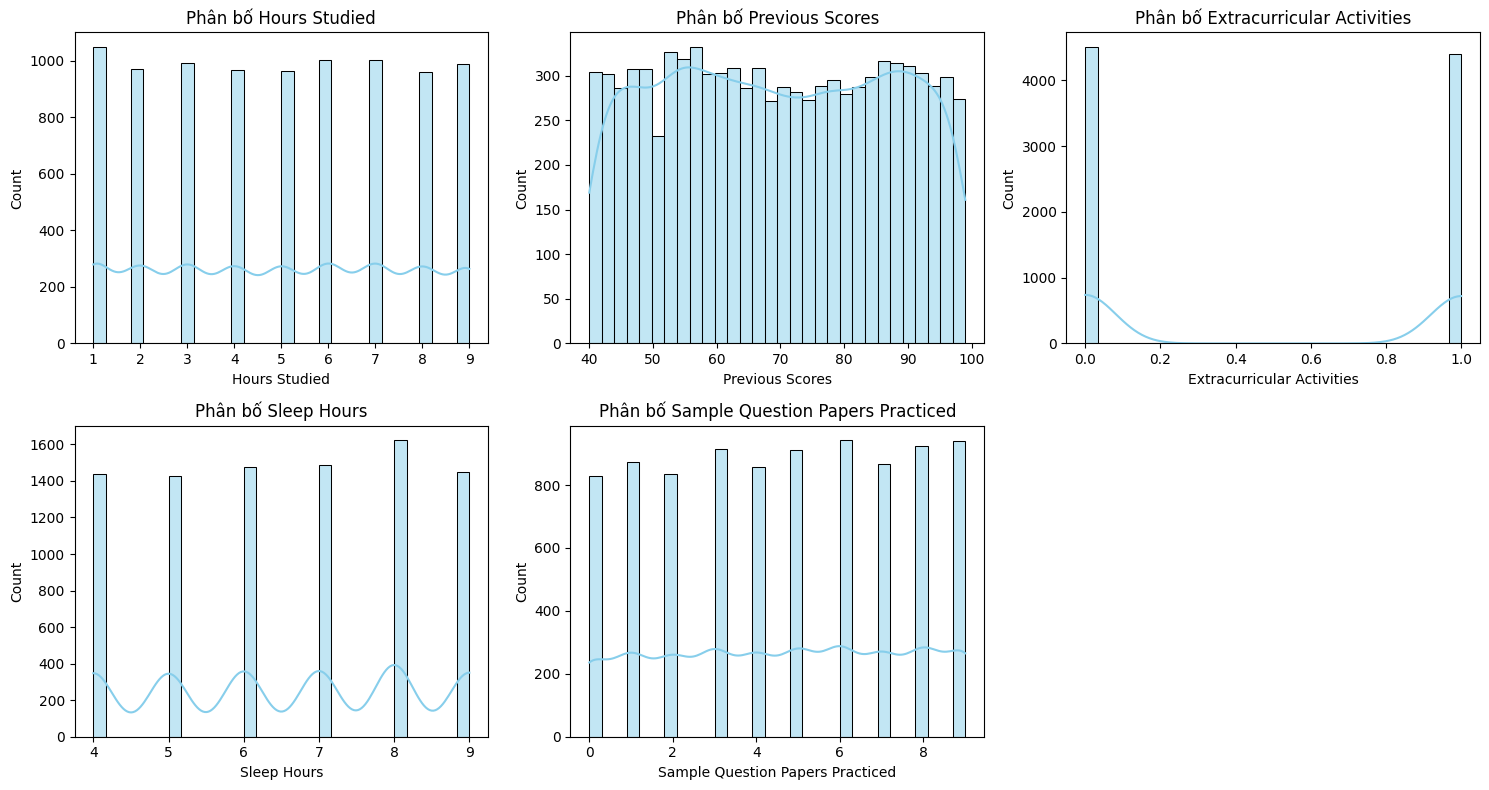

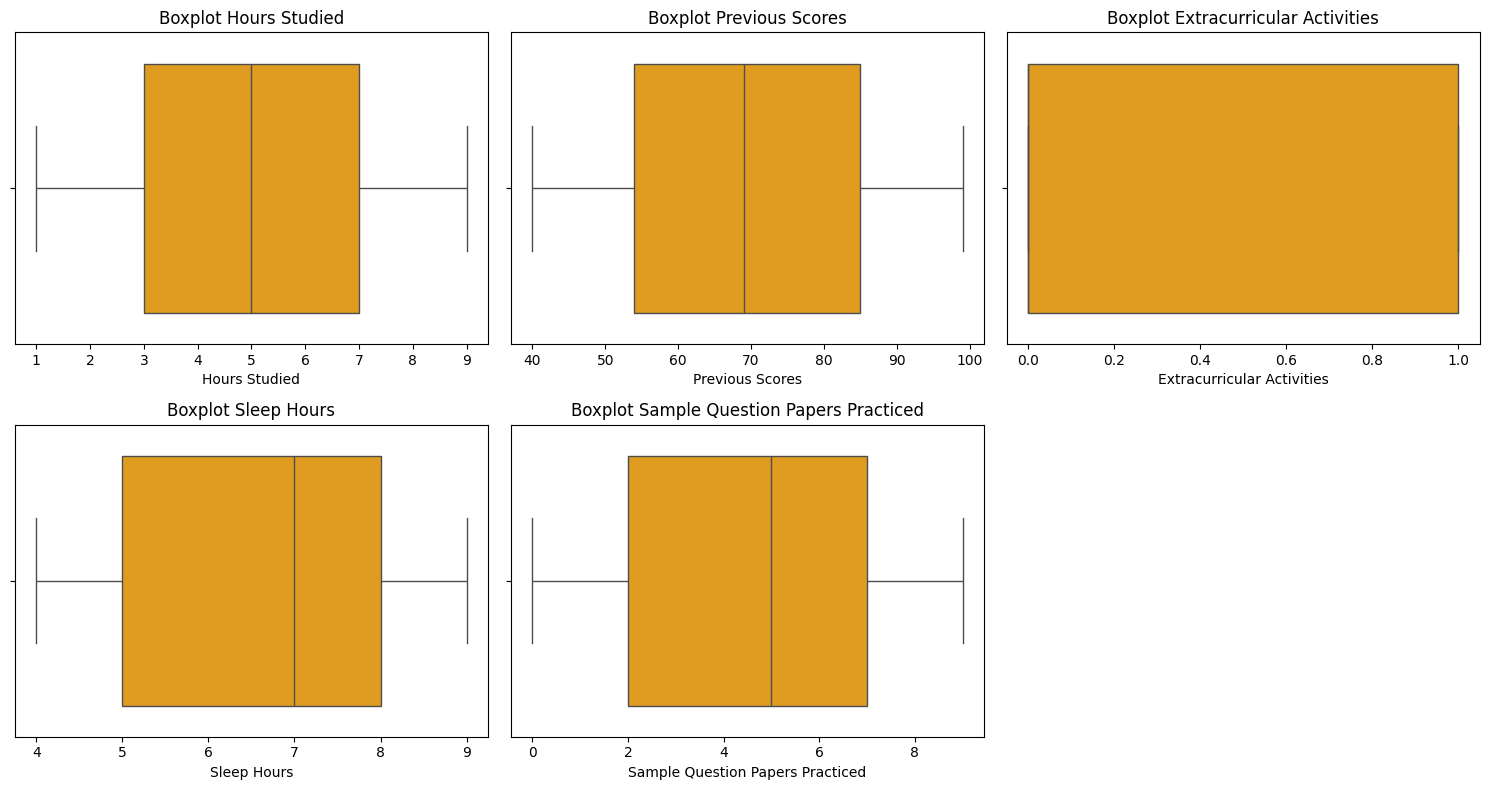

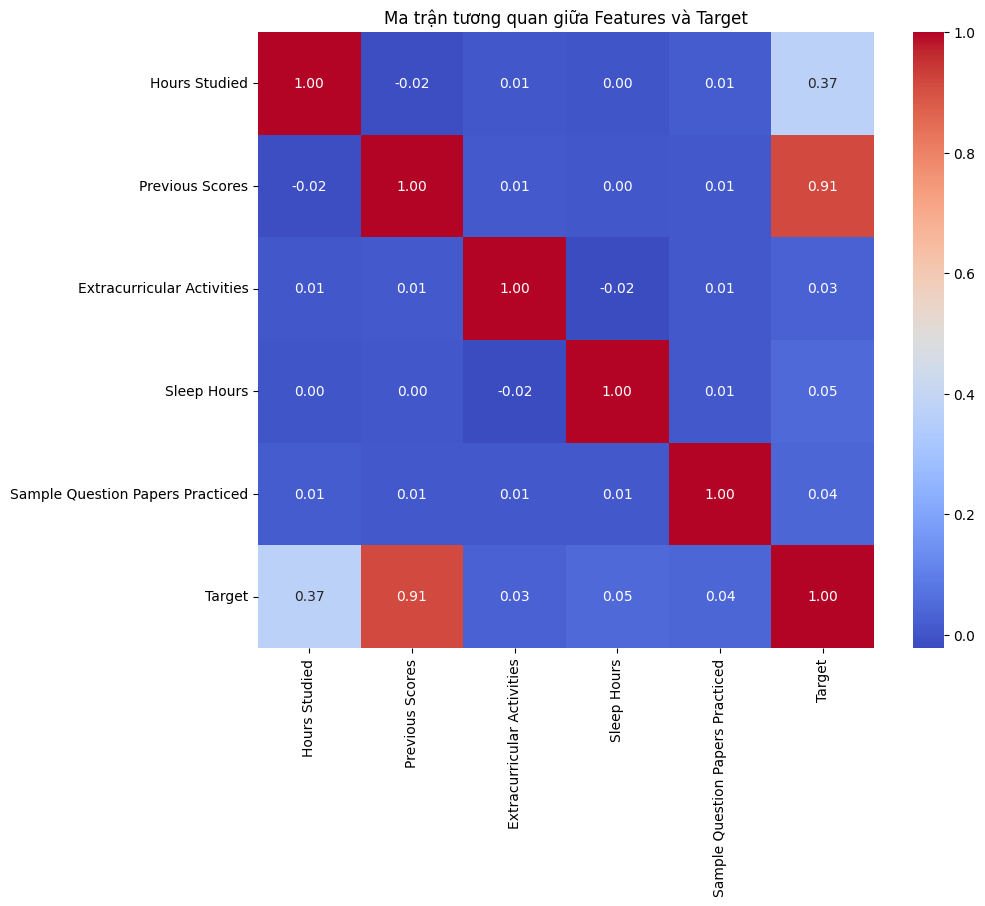

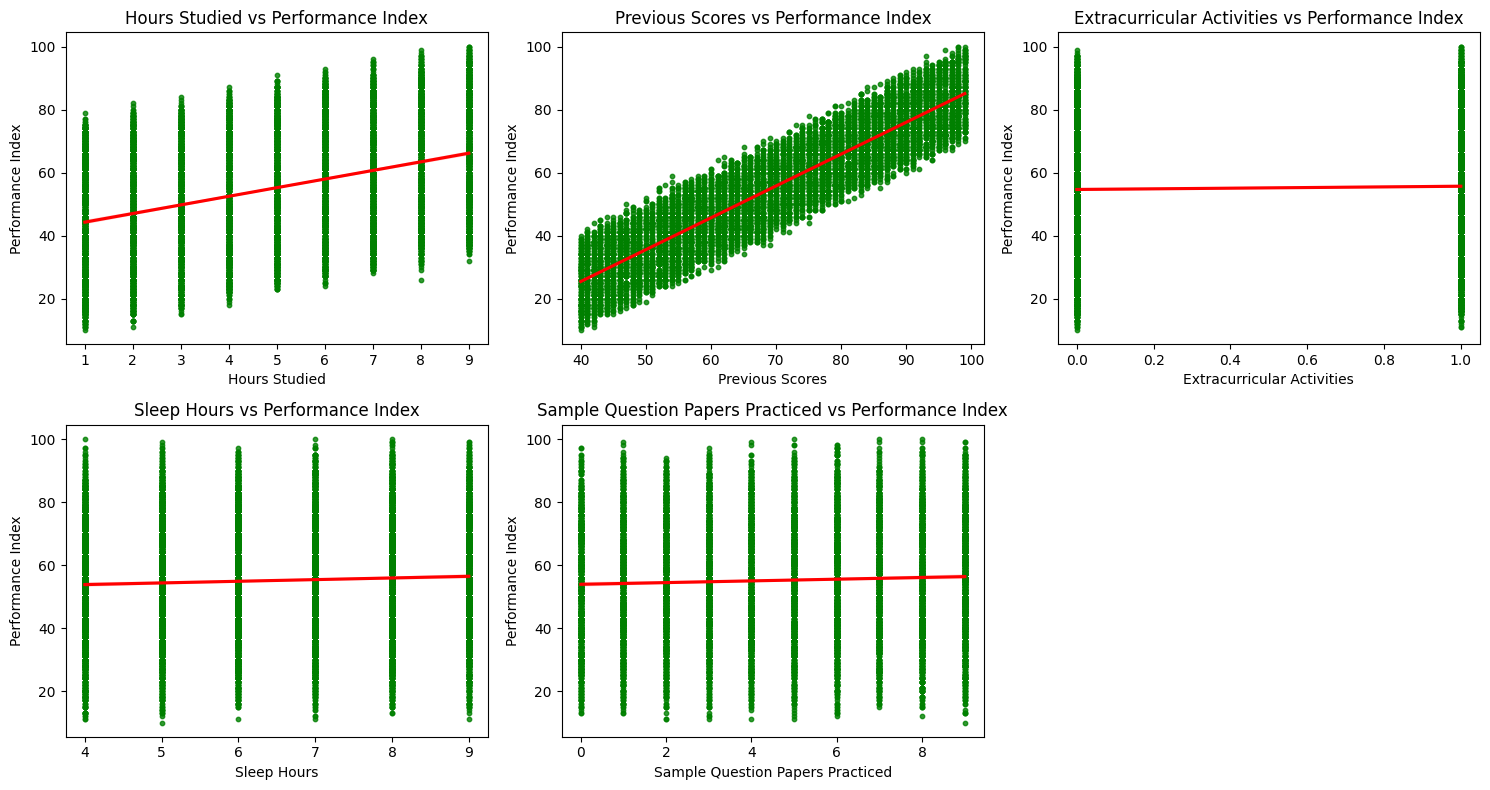

In [5]:
# Phân tích khám phá dữ liệu thông qua thống kê và các biểu đồ
# Chỉ được phân tích trên tập huấn luyện

def exploratory_data_analysis(X_train, y_train, feature_names, target_name):
    """Phân tích dữ liệu: thống kê, histogram, boxplot, heatmap, scatter"""
    print("\nThông tin tập huấn luyện:")
    X_train.info()
    print("Kiểu dữ liệu & số unique values:")
    for col in X_train.columns:
        print(f"{col}: {X_train[col].dtype}, unique: {X_train[col].nunique()}")
    print("\nThống kê mô tả:")
    print(X_train.describe())
    print("\nGiá trị thiếu:")
    print(X_train.isnull().sum())
    print(y_train.isnull().sum())

    # Kiểm tra và loại bỏ giá trị trùng lặp
    dup_train = train.duplicated().sum()
    dup_test = test.duplicated().sum()
    if dup_train > 0:
        train.drop_duplicates(inplace=True)
        X_train = train.iloc[:, :-1]
        y_train = train.iloc[:, -1]
    if dup_test > 0:
        test.drop_duplicates(inplace=True)
    print(f"\nSố dòng trùng lặp trong train: {dup_train}")
    print(f"Số dòng trùng lặp trong test: {dup_test}")

    # Histogram
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(feature_names, 1):
        plt.subplot(2, 3, i)
        sns.histplot(X_train[col], kde=True, bins=30, color='skyblue')
        plt.title(f'Phân bố {col}')
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(feature_names, 1):
        plt.subplot(2, 3, i)
        sns.boxplot(x=X_train[col], color='orange')
        plt.title(f'Boxplot {col}')
    plt.tight_layout()
    plt.show()

    # Heatmap
    df_corr = pd.concat([X_train, y_train], axis=1)
    df_corr = df_corr.rename(columns={y_train.name: "Target"})
    corr_matrix = df_corr.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
    plt.title('Ma trận tương quan giữa Features và Target')
    plt.show()

    # Scatter với đường hồi quy
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(feature_names, 1):
        plt.subplot(2, 3, i)
        sns.regplot(
            x=X_train[col],
            y=y_train,
            scatter_kws={'color': 'green', 's': 10},
            line_kws={'color': 'red'}
        )
        plt.title(f'{col} vs {target_name}')
    plt.tight_layout()
    plt.show()

# Phân tích khám phá dữ liệu
exploratory_data_analysis(X_train, y_train, feature_names, target_name)


# Yêu cầu 2a: Xây dựng mô hình sử dụng toàn bộ 5 đặc trưng đề bài cung cấp

In [6]:
# Phần code cho yêu cầu 2a
# Tính theta = (X^T X)^-1 X^T y
theta_all = train_linear_regression(X_train_np, y_train_np)

print("\nCông thức mô hình hồi quy tuyến tính:")
print_regression_formula(theta_all, feature_names)


Công thức mô hình hồi quy tuyến tính:
y = -33.969 + 2.852 * Hours Studied + 1.018 * Previous Scores + 0.604 * Extracurricular Activities + 0.474 * Sleep Hours + 0.192 * Sample Question Papers Practiced


In [7]:
# Gọi hàm MSE (tự cài đặt hoặc từ thư viện) trên tập kiểm tra
y_pred_test = X_test_np @ theta_all
print(f"MSE (test): {mse(y_test_np,y_pred_test):.3f}")

MSE (test): 4.093


Công thức hồi quy, phần trọng số làm tròn đến 3 chữ số thập phân, ví dụ 0.012345 $\to$ 0.012

$$\text{Student Performance} = -33.969 + 2.852 * Hours Studied + 1.018 * Previous Scores + 0.604 * Extracurricular Activities + 0.474 * Sleep Hours + 0.192 * Sample Question Papers Practiced$$

# Yêu cầu 2b: Xây dựng mô hình sử dụng duy nhất 1 đặc trưng, tìm mô hình cho kết quả tốt nhất

Lưu ý: Khi sử dụng cross-validation, sinh viên cần xáo trộn dữ liệu 1 lần duy nhất và thực hiện trên toàn bộ đặc trưng

In [8]:
# --- Phần 2b: Cross Validation cho từng đặc trưng ---
# Shuffle dữ liệu train 1 lần duy nhất
def cross_validate_single_feature(X_df, y_series, feature_name, k=5):
    """Cross-validation MSE cho 1 đặc trưng"""
    X = X_df[[feature_name]].to_numpy()
    y = y_series.to_numpy().reshape(-1, 1)
    X = np.hstack([np.ones((X.shape[0], 1)), X])

    # Shuffle
    indices = np.random.permutation(len(X))
    X, y = X[indices], y[indices]

    fold_size = len(X) // k
    mse_scores = []

    for fold in range(k):
        start = fold * fold_size
        end = start + fold_size if fold != k - 1 else len(X)
        val_idx = np.arange(start, end)
        train_idx = np.concatenate([np.arange(0, start), np.arange(end, len(X))])

        theta = train_linear_regression(X[train_idx], y[train_idx])
        y_val_pred = X[val_idx] @ theta
        mse_scores.append(mse(y[val_idx], y_val_pred))

    return np.mean(mse_scores)

results = [(feat, cross_validate_single_feature(X_train, y_train, feat)) for feat in feature_names]
for i, (feat, mse_avg) in enumerate(results, 1):
    print(f"{i:<5}{feat:<25}{mse_avg:.3f}")

best_feature, best_mse = min(results, key=lambda x: x[1])
print(f"\nĐặc trưng tốt nhất: {best_feature}, MSE trung bình: {best_mse:.3f}")


1    Hours Studied            318.210
2    Previous Scores          60.130
3    Extracurricular Activities368.110
4    Sleep Hours              367.540
5    Sample Question Papers Practiced367.732

Đặc trưng tốt nhất: Previous Scores, MSE trung bình: 60.130


In [9]:
# Huấn luyện lại mô hình best_feature_model với đặc trưng tốt nhất trên toàn bộ tập huấn luyện
X_train_best = np.hstack([np.ones((len(X_train), 1)), X_train[[best_feature]].to_numpy()])
X_test_best = np.hstack([np.ones((len(X_test), 1)), X_test[[best_feature]].to_numpy()])
theta_best = train_linear_regression(X_train_best, y_train_np)

print("\nCông thức mô hình tốt nhất:")
print_regression_formula(theta_best, [best_feature])




Công thức mô hình tốt nhất:
y = -14.989 + 1.011 * Previous Scores


In [10]:
# Gọi hàm MSE (tự cài đặt hoặc từ thư viện) trên tập kiểm tra với mô hình best_feature_model
print(f"MSE (test - best feature): {mse(y_test_np, X_test_best @ theta_best):.3f}")

MSE (test - best feature): 58.888


Công thức hồi quy (dựa trên mô hình đặc trưng tốt nhất), phần trọng số làm tròn đến 3 chữ số thập phân, ví dụ 0.012345 $\to$ 0.012

$$\text{Student Performance} = -14.989 + 1.011 * Previous Scores$$

# Yêu cầu 2c: Sinh viên tự xây dựng/thiết kế mô hình, tìm mô hình cho kết quả tốt nhất

## Xây dựng/Thiết kế mô hình

In [11]:
# ======== Yêu cầu 2c ========
def cross_validate_model(X_df, y_series, feature_list, transform_fn=None, k=5):
    """
    Cross-validation MSE cho mô hình với feature_list và hàm biến đổi transform_fn
    - feature_list: list tên cột trong X_df
    - transform_fn: hàm biến đổi nhận vào X (numpy) và trả về X biến đổi
    """
    X = X_df[feature_list].to_numpy()
    if transform_fn:
        X = transform_fn(X)
    # Thêm cột bias
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    y = y_series.to_numpy().reshape(-1, 1)

    # Shuffle
    indices = np.random.permutation(len(X))
    X, y = X[indices], y[indices]

    fold_size = len(X) // k
    mse_scores = []

    for fold in range(k):
        start = fold * fold_size
        end = start + fold_size if fold != k - 1 else len(X)
        val_idx = np.arange(start, end)
        train_idx = np.concatenate([np.arange(0, start), np.arange(end, len(X))])

        theta = train_linear_regression(X[train_idx], y[train_idx])
        y_val_pred = X[val_idx] @ theta
        mse_scores.append(mse(y[val_idx], y_val_pred))

    return np.mean(mse_scores)

# Xây dựng 3 mô hình khác nhau
models = [
    {
        "name": "Model 1:y = Previous score + Study hours",
        "features": [feature_names[0], feature_names[1]],
        "transform": None
    },
    {
        "name": "Model 2:y = Previous score squared + Study hours",
        "features": [feature_names[0], feature_names[1]],
        "transform": lambda X: np.column_stack([X[:,0]**2, X[:,1]])
    },
    {
        "name": "Model 3:y = Previous score * Study hours + Study hours",
        "features": [feature_names[0], feature_names[2]],
        "transform": lambda X: np.column_stack([X[:,0] * X[:,1], X[:,1]])
    }
]


## Tìm mô hình cho kết quả tốt nhất

Lưu ý: Khi sử dụng cross-validation, sinh viên cần xáo trộn dữ liệu 1 lần duy nhất và thực hiện trên toàn bộ $m$ mô hình mà sinh viên thiết kế

In [12]:
# Phần code cho yêu cầu 2c
# Tìm ra mô hình tốt nhất (trong m mô hình mà sinh viên tự thiết kế)
# In ra các kết quả cross-validation như yêu cầu

# Cross-validation cho từng mô hình
results_c2c = []
for m in models:
    mse_avg = cross_validate_model(X_train, y_train, m["features"], m["transform"], k=5)
    results_c2c.append((m["name"], m["features"], mse_avg, m["transform"]))
    print(f"{m['name']:<40} MSE trung bình: {mse_avg:.3f}")

# Chọn mô hình tốt nhất
best_model_name, best_features, best_mse_c2c, best_transform = min(results_c2c, key=lambda x: x[2])
print(f"\nMô hình tốt nhất: {best_model_name}, MSE CV trung bình: {best_mse_c2c:.3f}")


Model 1:y = Previous score + Study hours MSE trung bình: 5.200
Model 2:y = Previous score squared + Study hours MSE trung bình: 7.787
Model 3:y = Previous score * Study hours + Study hours MSE trung bình: 341.867

Mô hình tốt nhất: Model 1:y = Previous score + Study hours, MSE CV trung bình: 5.200


In [13]:
# Huấn luyện lại mô hình my_best_model trên toàn bộ tập huấn luyện
X_train_best_c2c = X_train[best_features].to_numpy()
if best_transform:
    X_train_best_c2c = best_transform(X_train_best_c2c)
X_train_best_c2c = np.hstack([np.ones((X_train_best_c2c.shape[0], 1)), X_train_best_c2c])

X_test_best_c2c = X_test[best_features].to_numpy()
if best_transform:
    X_test_best_c2c = best_transform(X_test_best_c2c)
X_test_best_c2c = np.hstack([np.ones((X_test_best_c2c.shape[0], 1)), X_test_best_c2c])

theta_best_c2c = train_linear_regression(X_train_best_c2c, y_train_np)

# In công thức
feature_names_final = (
    [f"{f}_transformed" for f in best_features]
    if best_transform else best_features
)
print("\nCông thức mô hình hồi quy tốt nhất:")
print_regression_formula(theta_best_c2c, feature_names_final)



Công thức mô hình hồi quy tốt nhất:
y = -29.747 + 2.856 * Hours Studied + 1.018 * Previous Scores


In [15]:
# Gọi hàm MSE (tự cài đặt hoặc từ thư viện) trên tập kiểm tra với mô hình my_best_model
y_pred_test = X_test_best_c2c @ theta_best_c2c
final_test_mse = mse(y_test_np, y_pred_test)
print(f"MSE trên tập kiểm tra của mô hình tốt nhất: {final_test_mse:.3f}")

MSE trên tập kiểm tra của mô hình tốt nhất: 5.393


Công thức hồi quy (dựa trên mô hình tốt nhất mà sinh viên tự xây dựng/thiết kế), phần trọng số làm tròn đến 3 chữ số thập phân, ví dụ 0.012345 $\to$ 0.012

$$\text{Student Performance} =  -29.747 + 2.856 * Hours Studied + 1.018 * Previous Scores$$